<a href="https://colab.research.google.com/github/RimadhaniAula/PCVK_genap2022/blob/main/Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


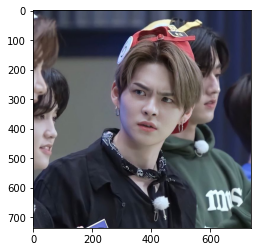

In [19]:
import cv2 as cv 
from google.colab.patches import cv2_imshow 
from skimage import io 
import matplotlib.pyplot as plt 
import numpy as np 

img = cv.imread('/content/drive/MyDrive/Divisi Komputer/yoci.tiff')
image = cv.cvtColor(img,cv.COLOR_BGR2RGB)
plt.imshow(image)

 Adjust Brightness to 50
---------------------------------


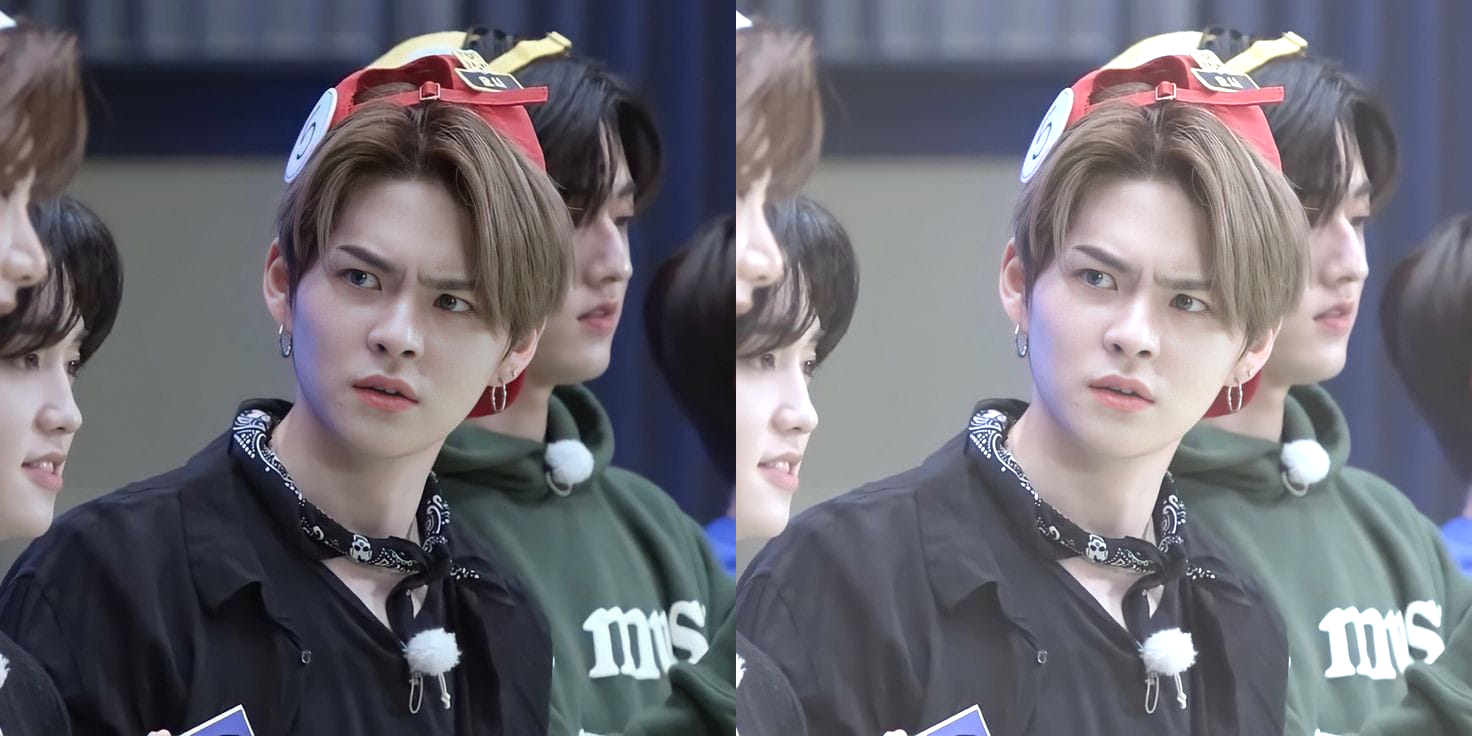

In [20]:
print(' Adjust Brightness to 50')
print('---------------------------------')

try:
    #brightness = int(input('Masukkan nilai kecerahan: '))
    brightness = int(50)
   
except ValueError:
    print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/Divisi Komputer/yoci.tiff')
brightness_image = np.zeros(original.shape, original.dtype)

#akses per piksel
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)

#cara simple tanpa for loop
#brightness_image = cv.convertScaleAbs(original, beta=brightness)

final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)

**TASK**

1 Implement contrast transformation in Google Collaboratory using the formula written in the Theoretical background section

Mengubah kontras dan tingkat kecerahan citra
--------------------------------------------
Masukkan nilai kecerahan [-255 - 255]: 60
Masukkan kontras [1.0 - 3.0]: 1.5


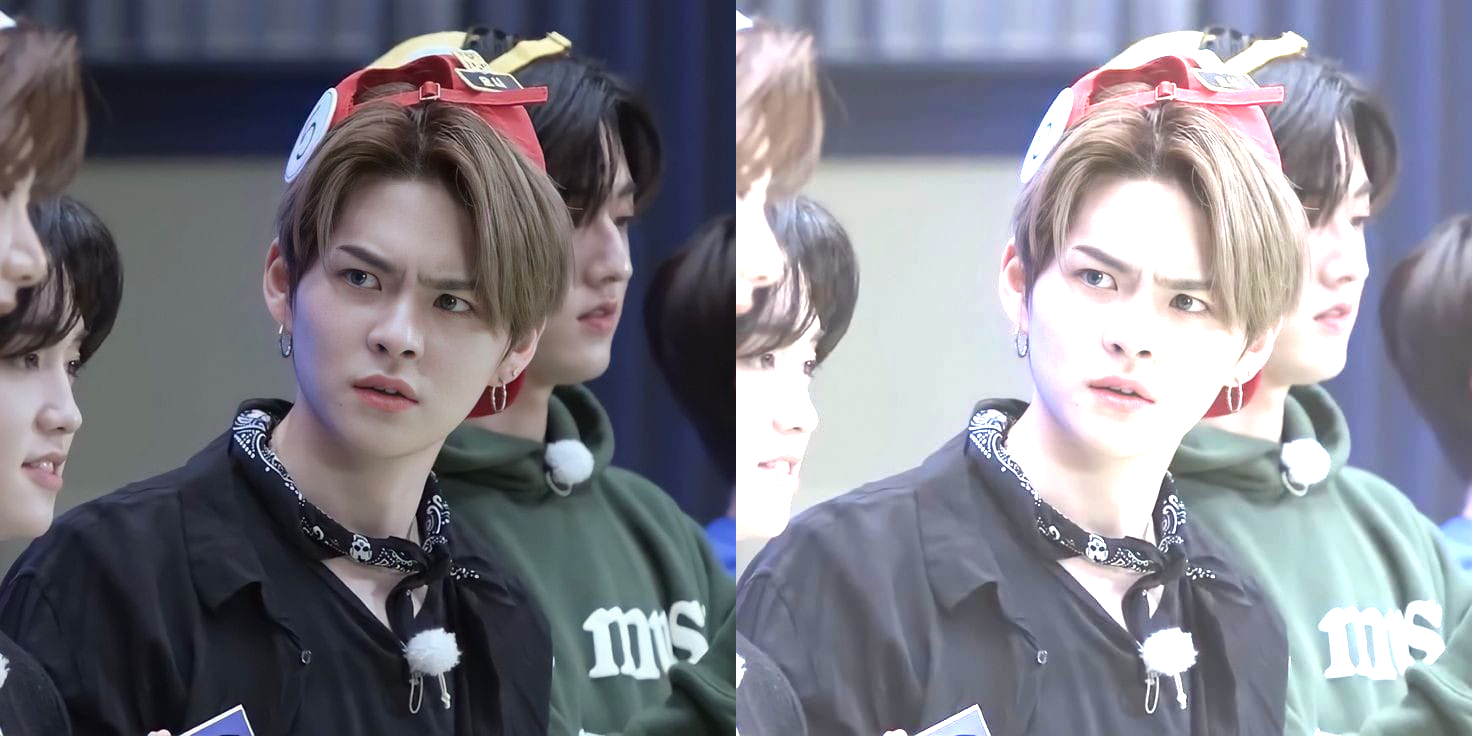

In [21]:
print('Mengubah kontras dan tingkat kecerahan citra')
print('--------------------------------------------')
try :
  brightness = int(input('Masukkan nilai kecerahan [-255 - 255]: '))
  contrast = float(input('Masukkan kontras [1.0 - 3.0]: '))
except ValueError:
  print('Error, not a number')


original = cv.imread('/content/drive/MyDrive/Divisi Komputer/yoci.tiff')
contrast_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
  for x in range(original.shape[1]):
    for c in range(original.shape[2]):
      contrast_image[y,x,c] = np.clip(contrast*original[y,x,c] + brightness, 0, 255)


final_frame = cv.hconcat((original, contrast_image))
cv2_imshow(final_frame)

2 Implement transformation of logarithmic brightness on Google Colaboratory using the formula written in the Theoretical Background Reviews,

Mengubah tingkat kecerahan citra dengan Transformasi Log
--------------------------------------------------------
Masukkan nilai kecerahan: 40


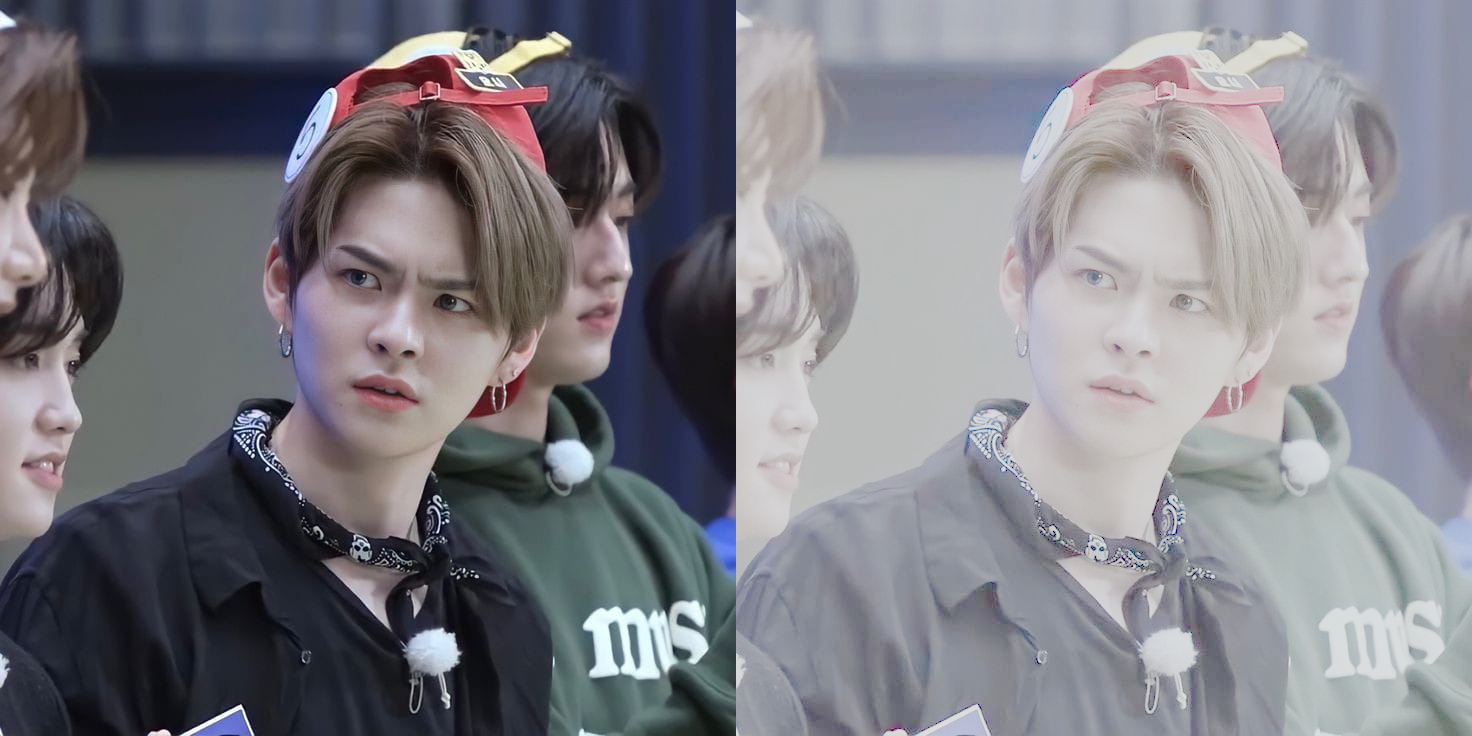

In [22]:
print('Mengubah tingkat kecerahan citra dengan Transformasi Log')
print('--------------------------------------------------------')
try:
  brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
  print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/Divisi Komputer/yoci.tiff')
brightness_image = np.zeros(original.shape, original.dtype)

# akses per piksel
for y in range(original.shape[0]):
  for x in range(original.shape[1]):
    for c in range(original.shape[2]):
      brightness_image[y,x,c] = np.clip(brightness * (np.log(1 + original[y,x,c])), 0, 255)

final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)

3 Implement grayscale transformation using the averaging, lightness, and luminance
method on Google Colaboratory using the formula written in the Theoretical 
Background Reviews

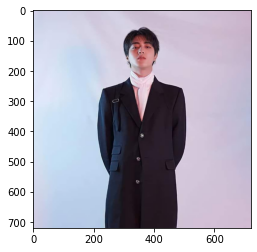

In [25]:
img_1 = cv.imread('/content/drive/MyDrive/Divisi Komputer/ruto.jpeg')
img_rgb = cv.cvtColor(img_1,cv.COLOR_BGR2RGB) # konversi channel BGR -> RGB
plt.imshow(img_rgb)

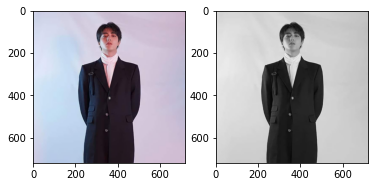

In [26]:
# A Averaging
img_avg = img_rgb
img_2 = cv.imread('/content/drive/MyDrive/Divisi Komputer/ruto.jpeg')
img_rgb1 = cv.cvtColor(img_2,cv.COLOR_BGR2RGB) # konversi channel BGR -> RGB

img_avg[:] = img_avg.mean(axis=-1, keepdims=1)
fig, ax = plt.subplots(1,2)
ax[0].imshow(img_rgb1)
ax[1].imshow(img_avg)

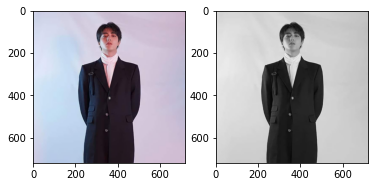

In [27]:
# B Lightness
img_light = img_rgb
img_light[:] = np.max(img_light,axis=-1,keepdims=10)/2+np.min(img_light,axis=-1,keepdims=10)/2
fig, ax = plt.subplots(1,2)
ax[0].imshow(img_rgb1)
ax[1].imshow(img_light)

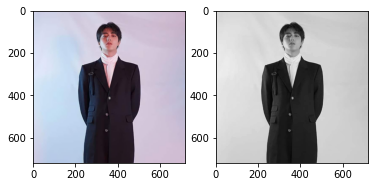

In [28]:
# C Luminance
image_lum = img_rgb
R, G, B = image_lum[:,:,0], image_lum[:,:,1], image_lum[:,:,2]
gray_image_lum = (0.21 * R) + (0.72 * G) + (0.07 * B)
fig, ax = plt.subplots(1,2)
ax[0].imshow(img_rgb1)
ax[1].imshow(gray_image_lum, cmap='gray')

4 Show certain colors in the image , and change other colors to grayscale.

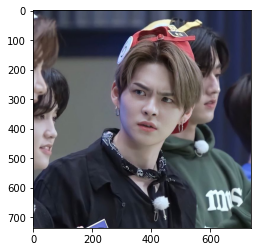

In [30]:
img_3 = cv.imread('/content/drive/MyDrive/Divisi Komputer/yoci.tiff')
img_rgb = cv.cvtColor(img_3,cv.COLOR_BGR2RGB) # konversi channel BGR -> RGB
plt.imshow(img_rgb)

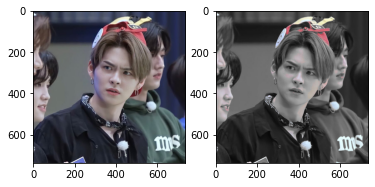

In [33]:
img_a = cv.imread('/content/drive/MyDrive/Divisi Komputer/yoci.tiff')
ret, mask = cv.threshold(img_a[:,:,2], 180, 255, cv.THRESH_BINARY)

mask3 = np.zeros_like(img_a)
mask3[:,:,0] = mask
mask3[:,:,1] = mask
mask3[:,:,2] = mask

red = cv.bitwise_and(img_rgb, mask3)

gray = cv.cvtColor(img_a, cv.COLOR_BGR2GRAY)
img_a = cv.cvtColor(gray, cv.COLOR_GRAY2BGR)

gray = cv.bitwise_and(img_a, 255 - mask3)

out = gray + red

fig, ax = plt.subplots(1,2)
ax[0].imshow(img_rgb)
ax[1].imshow(out, cmap='gray')